## Импорт библиотек и настройки окружения

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

RANDOM_SEED = 42

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from config import (
    MLFLOW_PORT
)
mlflow.set_tracking_uri("http://localhost:{}".format(MLFLOW_PORT))

Проверка подключения к MLflow

In [5]:
mlflow.search_experiments(max_results=3)

[<Experiment: artifact_location='s3://mlflow-bucket/mlflow/0', creation_time=1780510990264, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1780510990264, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]

## Подготовка датасета

In [6]:
class TargetEncoder:

    def __init__(
        self,
        smoothing: float = 0.0
    ) -> None:
        assert 0.0 <= smoothing <= 1.0, "smoothing must be in [0, 1]"
        self.smoothing = smoothing
        self.global_mean_: float = None
        self.encoding_maps_: dict[str, dict] = {}

    def fit(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        columns: list[str]
    ) -> "TargetEncoder":
        self.columns = columns
        self.global_mean_ = y.mean()
        for col in columns:
            cat_means = (
                pd.concat([X[col], y], axis=1)
                .groupby(col)[y.name]
                .mean()
            )
            encoded = (1 - self.smoothing) * cat_means + self.smoothing * self.global_mean_
            self.encoding_maps_[col] = encoded.to_dict()
        return self
    
    def transform(
        self,
        X: pd.DataFrame
    ) -> pd.DataFrame:
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.encoding_maps_[col]).fillna(self.global_mean_)
        return X

    def fit_transform(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        columns: list[str]
    ) -> pd.DataFrame:
        return self.fit(X, y, columns).transform(X)

In [14]:
df_train = pd.read_csv("./dataset/atm_train_split.csv", encoding='utf-8')
df_test = pd.read_csv("./dataset/atm_test_split.csv", encoding='utf-8')

In [15]:
df_train.reset_index(drop=True, inplace=True)

In [16]:
cat_cols = ["region", "atm_group"]

encoder = TargetEncoder(smoothing=0.1)
df_train_encoded = encoder.fit_transform(df_train, df_train["target"], columns=cat_cols)

df_test_encoded = encoder.transform(df_test)

In [17]:
FEATURE_COLS = [c for c in df_train.columns if c != "target"]

X_train = df_train[FEATURE_COLS].copy()
y_train = df_train["target"]

X_test = df_test[FEATURE_COLS].copy()
y_test = df_test["target"]

X_train_encoded = df_train_encoded[FEATURE_COLS]
X_test_encoded = df_test_encoded[FEATURE_COLS]

In [18]:
X_train["atm_group"] = X_train["atm_group"].astype(str)
X_test["atm_group"] = X_test["atm_group"].astype(str)

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

## Проведение эксперимента с MLflow

В ходе предыдущего исследования (DL_Experiments.ipynb) было выявлено, что Случайный лес (Random Forest) показывает лучшие результаты по сравнению с другими моделями. Поэтому в данном эксперименте мы будем использовать именно эту модель для предсказания популярности банкоматов.

In [19]:
from mlflow.tracking import MlflowClient

experiment_name = "geolocation_popularity_random_forest"
artifact_location = "mlflow-artifacts:/"
client = MlflowClient()

exp = mlflow.get_experiment_by_name(experiment_name)
if exp is None:
    exp_id = client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_location
    )
    print("Created experiment:", exp_id)
else:
    exp_id = exp.experiment_id
    print("Using existing experiment:", exp_id, "artifact_location=", exp.artifact_location)

mlflow.set_experiment(experiment_name)

registered_model_name = "geolocation_popularity_random_forest_tuned"

params = {
    'n_estimators': 357,
    'max_depth': 26,
    'min_samples_split': 6,
    'min_samples_leaf': 2,
    'max_features': 0.4117617376684628
}

Created experiment: 1


In [20]:
with mlflow.start_run(experiment_id=exp_id):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())
    model = RandomForestRegressor(**params, random_state=RANDOM_SEED, n_jobs=-1)
    model.fit(X_train_encoded, y_train)

    pred = model.predict(X_test_encoded)

    metrics = {
        "rmse": float(root_mean_squared_error(y_test, pred)),
        "mae": float(mean_absolute_error(y_test, pred)),
        "r2": float(r2_score(y_test, pred)),
    }

    mlflow.log_params(params)
    mlflow.log_metrics(metrics)

    signature = infer_signature(X_test, pred)

    model_info = mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        signature=signature,
        input_example=X_test.head(5),
        registered_model_name=registered_model_name
    )

    mlflow.log_input(
        mlflow.data.from_pandas(df_train, source="data/atm_train_split.csv"),
        context="training",
    )

    client = MlflowClient()
    new_version = model_info.registered_model_version
    client.set_model_version_tag(registered_model_name, new_version, "env", "PRD")
    client.set_registered_model_alias(registered_model_name, "prd", new_version)

    run_id = mlflow.active_run().info.run_id
    print("Run ID:", run_id)
    print("Registered model version:", new_version)
    print("Alias 'prd' points to version:", new_version)
    print("Metrics:", metrics)

Artifact URI for this run: mlflow-artifacts:/b89fc010d7d84c27b99ad090df044641/artifacts


/home/ubuntu22/hse/GeolocationPopularityHSE/venv/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/03 22:18:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 22:18:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle for

Run ID: b89fc010d7d84c27b99ad090df044641
Registered model version: 1
Alias 'prd' points to version: 1
Metrics: {'rmse': 0.04194628627091485, 'mae': 0.033101816567421075, 'r2': 0.7698621986274364}
🏃 View run efficient-stag-381 at: http://localhost:5050/#/experiments/1/runs/b89fc010d7d84c27b99ad090df044641
🧪 View experiment at: http://localhost:5050/#/experiments/1


## Анализ ошибок

Выделим топ худших предсказаний модели:

In [23]:
TOP_N = 100


rmses = np.sqrt((pred - y_test) ** 2)

result_df = X_test_encoded.copy()
result_df['true_value'] = y_test.values if isinstance(y_test, pd.Series) else y_test
result_df['predicted_value'] = pred
result_df['rmse'] = rmses
top_worst = result_df.nlargest(TOP_N, 'rmse')

Исследуем распределение признаков у худших предсказаний:

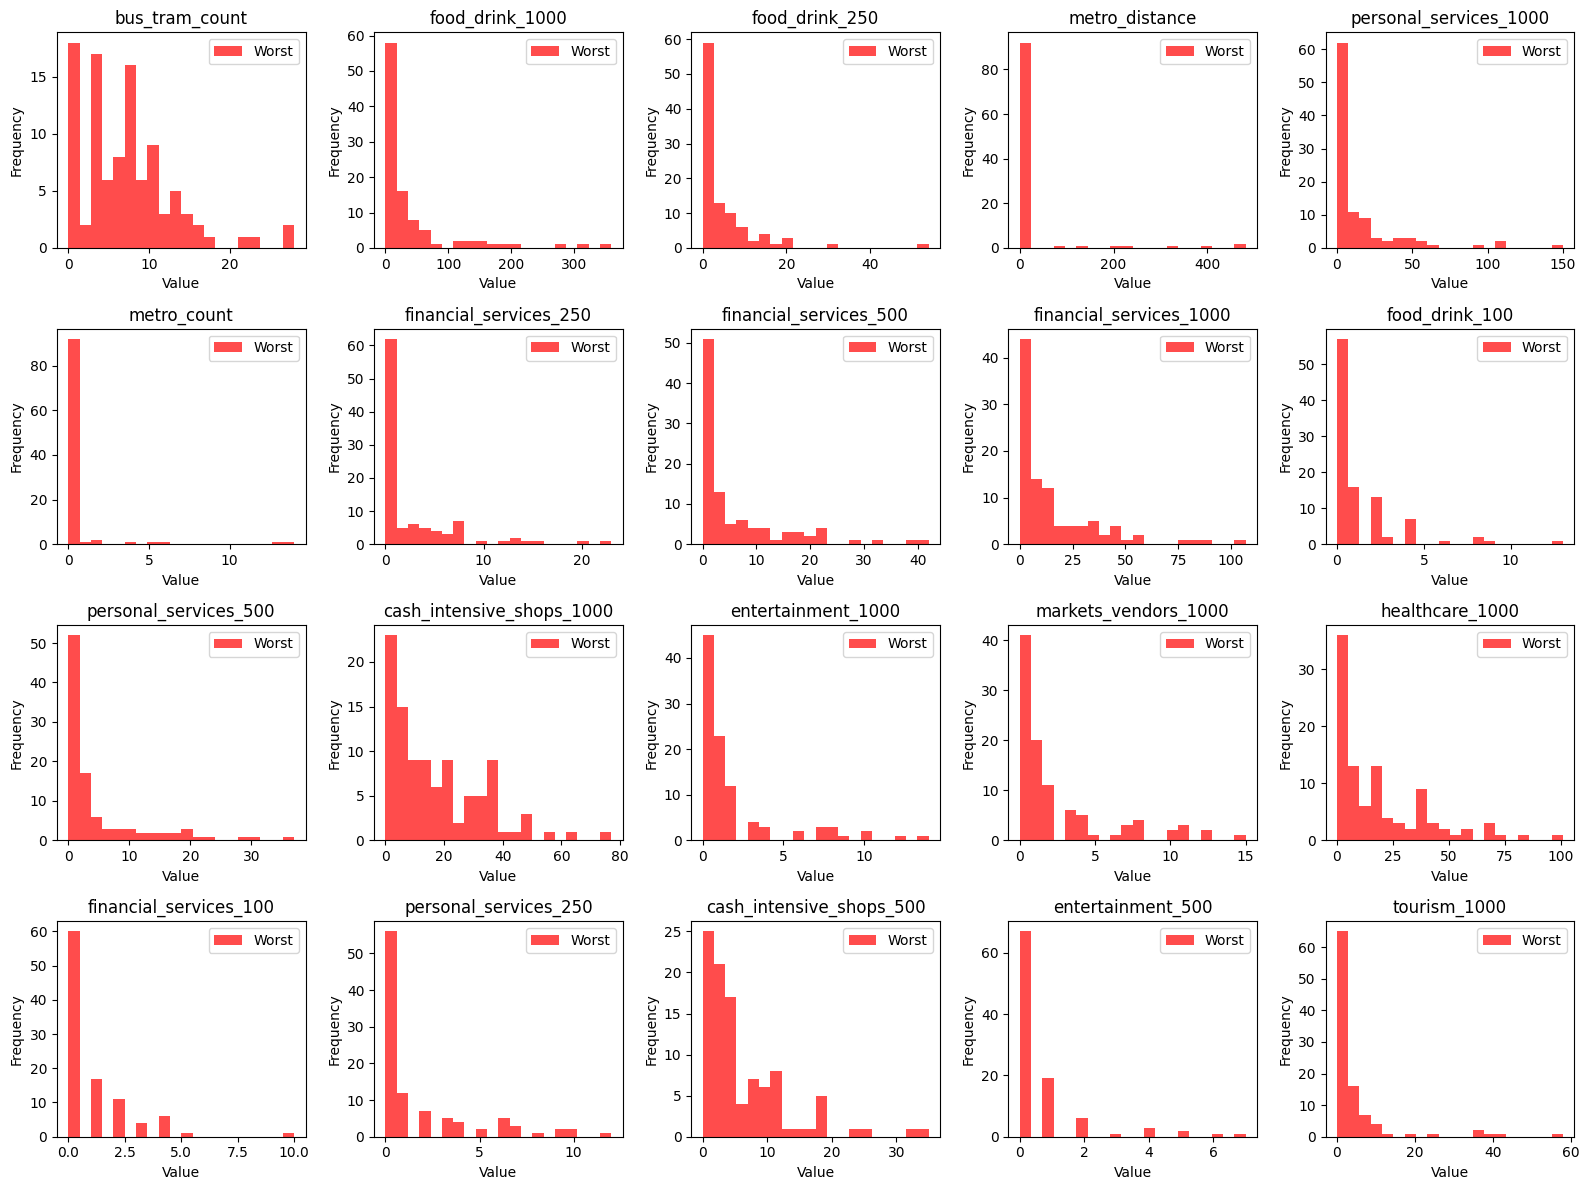

In [36]:
features = [
       'bus_tram_count', 'food_drink_1000', 'food_drink_250', 'metro_distance',
       'personal_services_1000', 'metro_count', 'financial_services_250',
       'financial_services_500', 'financial_services_1000', 'food_drink_100',
       'personal_services_500', 'cash_intensive_shops_1000',
       'entertainment_1000', 'markets_vendors_1000', 'healthcare_1000',
       'financial_services_100', 'personal_services_250',
       'cash_intensive_shops_500', 'entertainment_500', 'tourism_1000']

fig, axes = plt.subplots(4, len(features) // 4, figsize=(16, 12))

for idx, feature in enumerate(features):
    row = idx // (len(features) // 4)
    col = idx % (len(features) // 4)
    axes[row, col].hist(top_worst[feature], bins=20, alpha=0.7, label='Worst', color='red')
    axes[row, col].set_title(f'{feature}')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

**Выводы**:
- Большинство худших предсказаний приходится на банкоматы с отсутствием данных об окружающих объектах (например, магазины, кафе и т.д.), что может быть вызвано проблоемой сбора данных или их неполнотой;
- Целевая переменная (популярность) была получена в 2019 году, в то время как признаки были собраны в 2026 году, что может привести к несоответствию данных и ухудшению качества модели.

## Проверка устойчивости модели к изменениям данных

Добавим шум к тестовым данным и посмотрим, как изменится качество модели:

In [39]:
def add_gaussian_noise(X, noise_level=0.05):
    X_noisy = X.copy()
    for col in X.columns:
        if X[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            noise_std = noise_level * X[col].std()
            X_noisy[col] += np.random.normal(0, noise_std, size=len(X))
    return X_noisy

In [40]:
with mlflow.start_run(experiment_id=exp_id):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())
    model = RandomForestRegressor(**params, random_state=RANDOM_SEED, n_jobs=-1)
    model.fit(X_train_encoded, y_train)
    pred_clean = model.predict(X_test_encoded)
    base_rmse = root_mean_squared_error(y_test, pred_clean)
    noise_levels = [0.01, 0.05, 0.1, 0.15, 0.2]

    for noise_level in noise_levels:
        X_test_noisy = add_gaussian_noise(X_test_encoded, noise_level)
        pred_noisy = model.predict(X_test_noisy)
        rmse_noisy = root_mean_squared_error(y_test, pred_noisy)
        degradation = ((rmse_noisy - base_rmse) / base_rmse) * 100
        
        mlflow.log_metric(f"rmse_{int(noise_level*100)}pct_noise", rmse_noisy)
        mlflow.log_metric(f"degradation_{int(noise_level*100)}pct", degradation)
    
    mlflow.log_metric("rmse_baseline", base_rmse)
    mlflow.log_metric("mae_baseline", mean_absolute_error(y_test, pred_clean))
    mlflow.log_metric("r2_baseline", r2_score(y_test, pred_clean))
    mlflow.log_params(params)
    mlflow.log_param("noise_levels", str(noise_levels))
    
    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print(f"Baseline RMSE: {base_rmse:.4f}")

Artifact URI for this run: mlflow-artifacts:/abc1d9ed481d4f768dadd0edaa05374d/artifacts
Run ID: abc1d9ed481d4f768dadd0edaa05374d
Baseline RMSE: 0.0419
🏃 View run invincible-gull-708 at: http://localhost:5050/#/experiments/1/runs/abc1d9ed481d4f768dadd0edaa05374d
🧪 View experiment at: http://localhost:5050/#/experiments/1


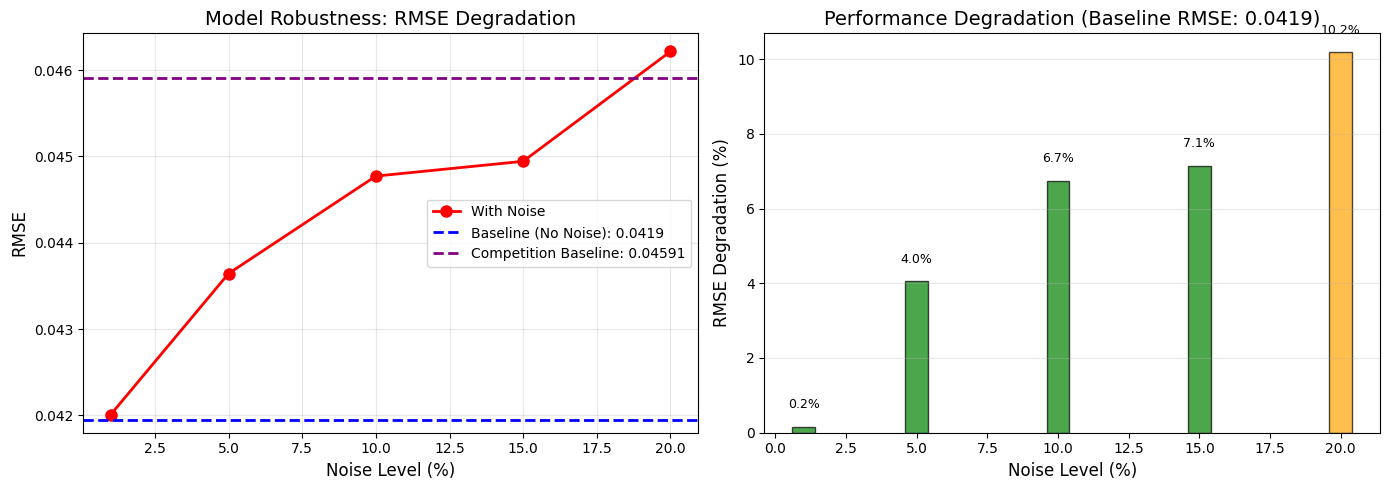

In [46]:
experiment = mlflow.get_experiment(exp_id)
runs = mlflow.search_runs(experiment_ids=[exp_id], order_by=["start_time DESC"], max_results=1)
run_id = runs.iloc[0].run_id

run = mlflow.get_run(run_id)
metrics = run.data.metrics

base_rmse = metrics['rmse_baseline']
base_mae = metrics['mae_baseline']
base_r2 = metrics['r2_baseline']

noise_levels = [1, 5, 10, 15, 20]
rmse_noisy = [metrics[f'rmse_{pct}pct_noise'] for pct in noise_levels]
degradations = [metrics[f'degradation_{pct}pct'] for pct in noise_levels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(noise_levels, rmse_noisy, 'o-', linewidth=2, markersize=8, color='red', label='With Noise')
ax1.axhline(y=base_rmse, color='blue', linestyle='--', linewidth=2, label=f'Baseline (No Noise): {base_rmse:.4f}')
ax1.axhline(y=0.04591, color='purple', linestyle='--', linewidth=2, label=f'Competition Baseline: 0.04591')
ax1.set_xlabel('Noise Level (%)', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Model Robustness: RMSE Degradation', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
colors = ['green' if d < 10 else 'orange' if d < 20 else 'red' for d in degradations]
ax2.bar(noise_levels, degradations, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Noise Level (%)', fontsize=12)
ax2.set_ylabel('RMSE Degradation (%)', fontsize=12)
ax2.set_title(f'Performance Degradation (Baseline RMSE: {base_rmse:.4f})', fontsize=14)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

for i, (level, deg) in enumerate(zip(noise_levels, degradations)):
    ax2.text(level, deg + 0.5, f'{deg:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Выводы**
- Модель показывает устойчивость к изменениям данных - при добавлении шума до 20% RMSE увеличивается на 10%;
- При добавлении шума в пределах 15%, модель все еще проходит нижний порог качества соревнования.

## Заключение

Лучший результат - Random Forest:
- RMSE: 0.0419
- MAE: 0.0331
- R²: 0.7699

Основная причина ошибок - устаревшие и не точные данные о расположении банкоматов и окружающих объектов.

Модель показывает устойчивость к изменениям данных - при добавлении шума до 20% RMSE увеличивается на 10%.